In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn import set_config
import warnings

warnings.filterwarnings('ignore')
set_config(display='diagram')

In [2]:
df = pd.read_csv('ford.csv')

In [3]:
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [4]:
df.shape

(17966, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [6]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

1. model - > Ford Car Brands
2. year - >Production Year
3. price - >Price of car in $
4. transmission - > Automatic,Manual, Semi-Auto
5. mileage -> Number of miles traveled
6. fuel_Type -> Petrol,Diesel,Hybrid,Electric,Other
7. tax -> Annual Tax
8. mpg - > Miles per Gallon
9. engineSize - > Car's Engine Size

## Numerical Features — Descriptive Statistics

In [7]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


### Observation

- The dataset contains 17,966 observations.
- `price` has a mean of approximately £12,279 and a median of £11,291, indicating that the price distribution is right-skewed.
- `year` ranges from 1996 to 2060. The value 2060 appears suspicious and will be investigated.
- `mileage` is strongly right-skewed, with a maximum of 177,644.
- `engineSize` has a minimum of 0, which may represent missing information.
- `mpg` has a maximum of 201.8, which will be investigated.

## Categorical Features — Descriptive Statistics

In [8]:
df.describe(include='object')

,model,transmission,fuelType
count,17966,17966,17966
unique,24,3,5
top,Fiesta,Manual,Petrol
freq,6557,15518,12179


In [9]:
num_features = df.select_dtypes(include='number')
cat_features = df.select_dtypes(include='object')

In [10]:
for col in cat_features:
  print(f'\n{'='* 20}')
  print(f'Column : {col}')
  print(df[col].value_counts(dropna= False))


Column : model
model
 Fiesta                   6557
 Focus                    4588
 Kuga                     2225
 EcoSport                 1143
 C-MAX                     543
 Ka+                       531
 Mondeo                    526
 B-MAX                     355
 S-MAX                     296
 Grand C-MAX               247
 Galaxy                    228
 Edge                      208
 KA                        199
 Puma                       80
 Tourneo Custom             69
 Grand Tourneo Connect      59
 Mustang                    57
 Tourneo Connect            33
 Fusion                     16
 Streetka                    2
 Ranger                      1
 Escort                      1
 Transit Tourneo             1
Focus                        1
Name: count, dtype: int64

Column : transmission
transmission
Manual       15518
Automatic     1361
Semi-Auto     1087
Name: count, dtype: int64

Column : fuelType
fuelType
Petrol      12179
Diesel       5762
Hybrid         22
Electri

### Observation

- `model` has 24 unique values, with `Fiesta` being the most common model.
- `transmission` has 3 categories, with `Manual` being dominant.
- `fuelType` has 5 categories, with `Petrol` being dominant.
- All categorical columns contain 17,966 non-null values, so there are no missing values in these columns.

In [11]:
df["model"].unique()

array([' Fiesta', ' Focus', ' Puma', ' Kuga', ' EcoSport', ' C-MAX',
       ' Mondeo', ' Ka+', ' Tourneo Custom', ' S-MAX', ' B-MAX', ' Edge',
       ' Tourneo Connect', ' Grand C-MAX', ' KA', ' Galaxy', ' Mustang',
       ' Grand Tourneo Connect', ' Fusion', ' Ranger', ' Streetka',
       ' Escort', ' Transit Tourneo', 'Focus'], dtype=object)

### Observation

- `model` contains both `' Focus'` and `'Focus'`.
- `' Focus'` has a leading whitespace, causing Pandas to treat it as a separate category.
- `transmission` and `fuelType` do not contain similar whitespace issues.
- The `model` column will be cleaned using `.str.strip()` during the data-cleaning stage.

In [12]:
df[df["year"] > 2025]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
17726,Fiesta,2060,6495,Automatic,54807,Petrol,205,42.8,1.4


In [13]:
df[df["engineSize"] == 0]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
13862,Kuga,2019,18990,Manual,8389,Petrol,150,35.3,0.0
14064,Focus,2016,15500,Manual,28344,Diesel,20,67.3,0.0
14082,Focus,2015,14300,Manual,40457,Diesel,20,67.3,0.0
15343,KA,2018,10000,Manual,10051,Petrol,150,43.5,0.0
15500,EcoSport,2015,8500,Manual,33403,Diesel,30,61.4,0.0
15775,Focus,2017,13000,Manual,24484,Diesel,145,70.6,0.0
16312,Focus,2015,9170,Manual,28000,Petrol,20,61.4,0.0
16313,Focus,2019,18699,Manual,10000,Petrol,145,46.3,0.0
16321,Fiesta,2017,9899,Manual,10000,Petrol,0,65.7,0.0
16322,Ka+,2018,9999,Manual,15000,Petrol,145,43.5,0.0


In [14]:
df[df["mpg"] > 150]

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
6153,Kuga,2020,31000,Semi-Auto,10,Hybrid,135,201.8,2.5
6536,Kuga,2020,31991,Semi-Auto,2357,Hybrid,135,201.8,2.5
9220,Kuga,2020,32000,Automatic,10,Hybrid,140,201.8,2.5
12862,Kuga,2020,33500,Automatic,5534,Hybrid,140,201.8,2.5
13730,Kuga,2020,32995,Automatic,11,Hybrid,135,201.8,2.5


In [15]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


## Checking for Duplicate Rows

In [16]:
df.duplicated().sum()

np.int64(154)

In [17]:
df[df.duplicated()].head(10)

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
159,Focus,2016,10995,Manual,30923,Diesel,0,74.3,1.5
312,Focus,2019,14998,Manual,7000,Petrol,145,58.9,1.0
349,Focus,2019,14998,Manual,7000,Petrol,145,58.9,1.0
510,EcoSport,2019,15489,Manual,5636,Diesel,145,68.9,1.5
512,Grand Tourneo Connect,2019,19999,Manual,3500,Diesel,145,61.4,1.5
556,Grand Tourneo Connect,2018,15990,Automatic,9486,Diesel,145,56.6,1.5
557,Fiesta,2018,10990,Manual,28138,Petrol,145,56.5,1.0
559,EcoSport,2017,9489,Manual,29500,Petrol,145,52.3,1.0
1575,Focus,2018,17989,Manual,19653,Petrol,145,41.5,2.0
2129,Kuga,2019,16995,Manual,13255,Diesel,145,47.9,2.0


### Observation

- The dataset contains 154 exact duplicate rows.
- These rows contain identical values across all columns.
- They will be removed during the data-cleaning stage to prevent duplicate observations from receiving extra weight during model training.

In [18]:
df.nunique()

,0
model,24
year,23
price,3511
transmission,3
mileage,13528
fuelType,5
tax,36
mpg,90
engineSize,16


## Distribution of Car Prices

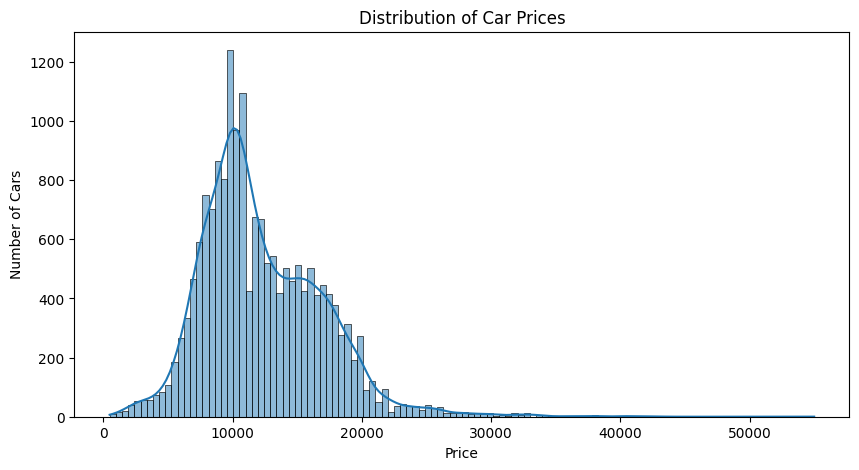

In [19]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="price", kde=True)
plt.title("Distribution of Car Prices")
plt.xlabel("Price")
plt.ylabel("Number of Cars")
plt.show()

### Observation

- The majority of car prices are concentrated approximately between £8,000 and £18,000.
- The distribution is **right-skewed**, with a long tail extending toward higher prices.
- The mean price (£12,279) is greater than the median price (£11,291), which supports the presence of right skewness.
- A small number of cars have considerably higher prices, reaching approximately £55,000.
- These high-priced observations are not automatically considered errors because they may represent genuinely expensive Ford models.

## Distribution of Numerical Features

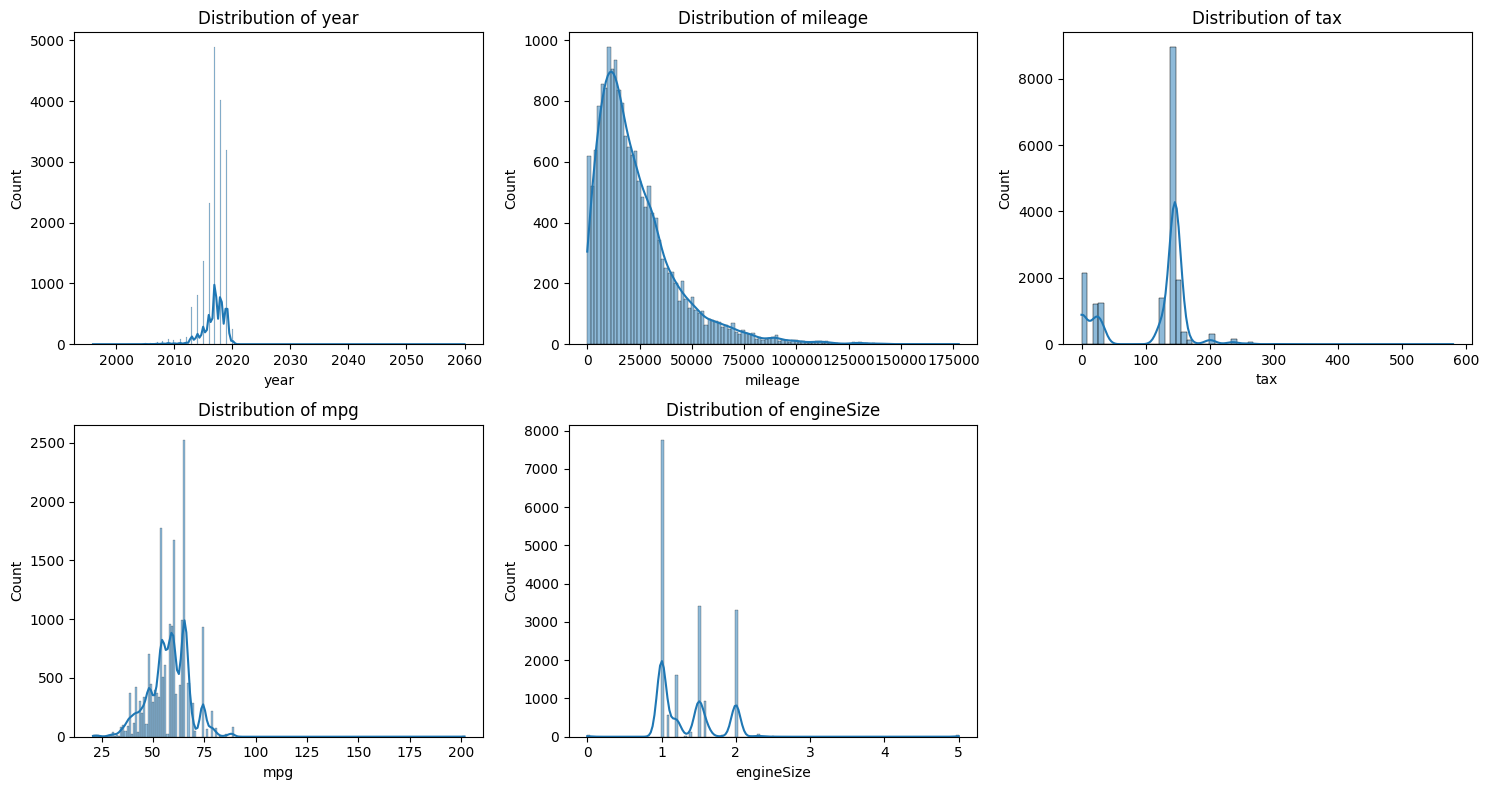

In [20]:
num_cols = ["year", "mileage", "tax", "mpg", "engineSize"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

axes[-1, -1].axis("off")

plt.tight_layout()
plt.show()

### Observation

#### Year
- Most cars are concentrated around the years 2015–2020.
- The value 2060 is clearly separated from the main distribution and is likely an invalid value.

#### Mileage
- `mileage` is strongly right-skewed.
- Most cars have relatively low to moderate mileage, while a smaller number have very high mileage.
- The maximum mileage of 177,644 is extreme but may still represent a legitimate used car.

#### Tax
- `tax` has a discrete distribution with large concentrations around certain values, particularly around 0, 145, and 150.
- This is expected because vehicle tax values occur in specific bands rather than being uniformly continuous.

#### MPG
- Most observations are concentrated roughly between 40 and 80 MPG.
- The distribution contains several peaks.
- The value 201.8 MPG appears unusual but was found to belong to 2020 Kuga Hybrid cars, so it appears legitimate.

#### Engine Size
- Most engine sizes are concentrated around common values such as 1.0, 1.2, 1.5, and 2.0 litres.
- There are 50 observations with `engineSize = 0`.
- Since 0 is not a meaningful engine size for these vehicles, these values will be treated as missing information.

## Year vs Price & Mileage vs Price


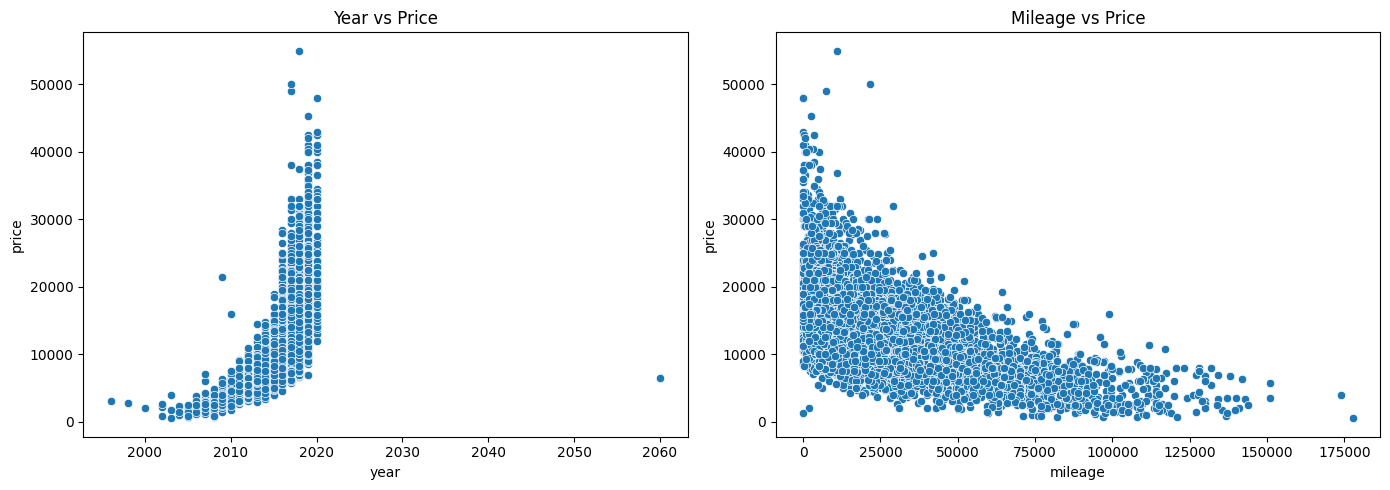

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.scatterplot(data=df, x="year", y="price", ax=axes[0])
axes[0].set_title("Year vs Price")

sns.scatterplot(data=df, x="mileage", y="price", ax=axes[1])
axes[1].set_title("Mileage vs Price")

plt.tight_layout()
plt.show()

### Observation

- There is a positive relationship between `year` and `price`.
- Newer cars generally have higher prices.
- The relationship does not appear perfectly linear; prices increase more sharply for newer cars.
- The observation with `year = 2060` is clearly anomalous.

- There is a negative relationship between `mileage` and `price`.
- Cars with higher mileage generally have lower prices.
- The relationship is not perfectly linear.
- Mileage is strongly right-skewed, with some cars having very high mileage.

## Other Numerical Features vs Price

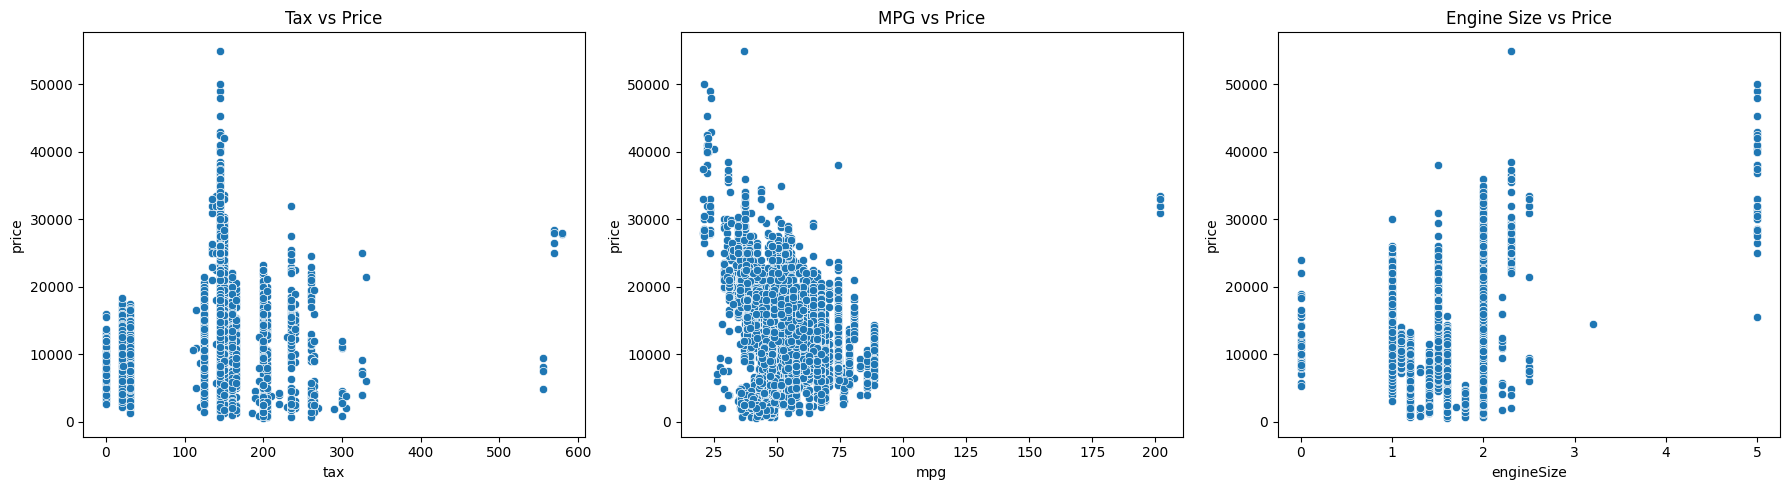

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.scatterplot(data=df, x="tax", y="price", ax=axes[0])
axes[0].set_title("Tax vs Price")

sns.scatterplot(data=df, x="mpg", y="price", ax=axes[1])
axes[1].set_title("MPG vs Price")

sns.scatterplot(data=df, x="engineSize", y="price", ax=axes[2])
axes[2].set_title("Engine Size vs Price")

plt.tight_layout()
plt.show()

### Observation

- `tax` does not show a strong clear linear relationship with `price`.
- `mpg` shows a generally negative relationship with `price`.
- `engineSize` shows a generally positive relationship with `price`.
- The relationship between `engineSize` and `price` is not perfectly linear.
- The `engineSize = 0` values appear suspicious and will be treated as missing information.
- The `mpg = 201.8` values belong to 2020 Kuga Hybrid cars and appear legitimate, so they will be retained.

## Price Distribution by Ford Model

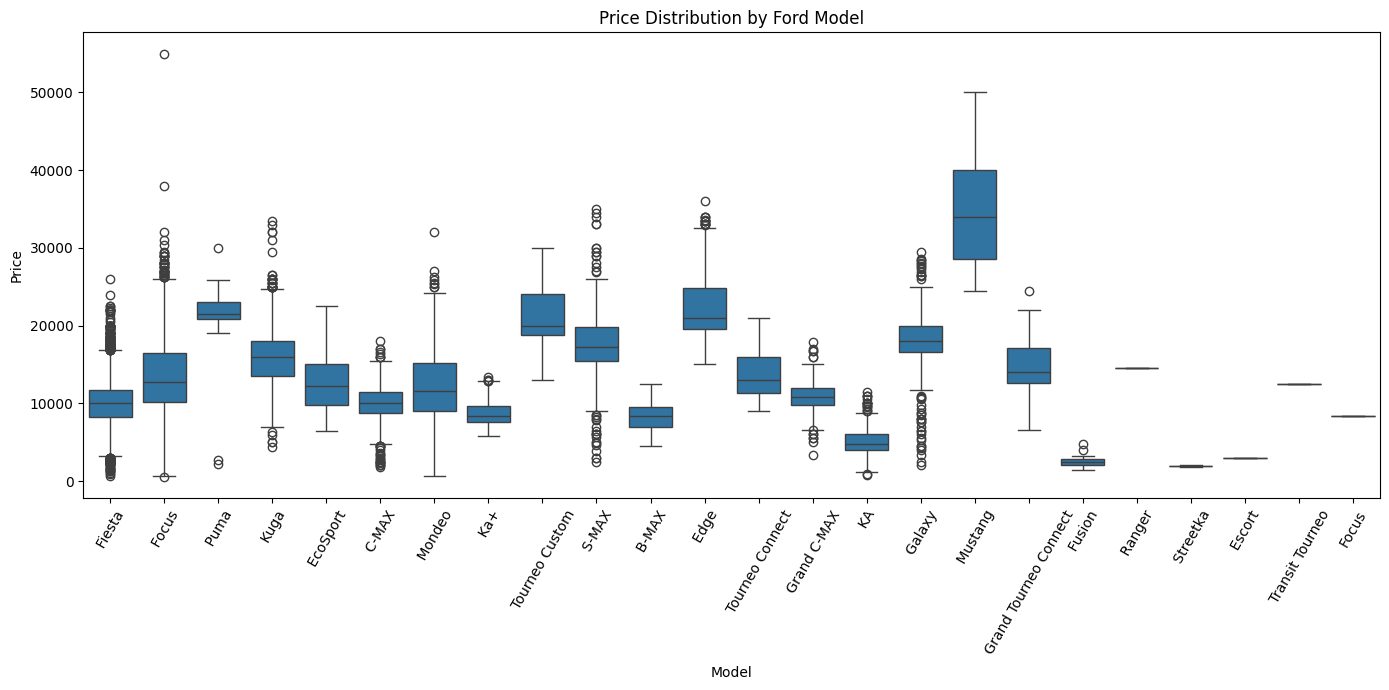

In [23]:
plt.figure(figsize=(14, 7))

sns.boxplot(data=df, x="model", y="price")

plt.xticks(rotation=60)
plt.title("Price Distribution by Ford Model")
plt.xlabel("Model")
plt.ylabel("Price")
plt.tight_layout()
plt.show()

### Observation

- `model` has a strong relationship with `price`.
- Different Ford models have noticeably different price distributions.
- Mustang, for example, has a much higher typical price than models such as Fiesta or KA.
- There are many statistical outliers within some models, but they will not automatically be removed because they may represent legitimate expensive cars.
- `model` should be one-hot encoded rather than label encoded because the categories have no natural numerical order.

## Price Distribution by Transmission

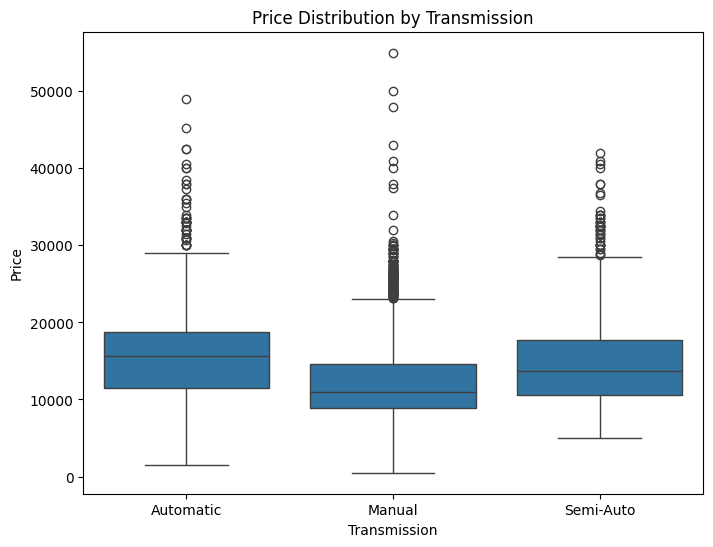

In [24]:
plt.figure(figsize=(8, 6))

sns.boxplot(data=df, x="transmission", y="price")

plt.title("Price Distribution by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Price")

plt.show()

### Observation

- Automatic cars have a higher typical price than manual cars.
- Semi-Auto generally falls between Automatic and Manual.
- There is a noticeable relationship between transmission type and price.
- Manual cars are heavily dominant in the dataset.
- The category imbalance is not a major issue because this is a regression problem.

## Price Distribution by Fuel Type

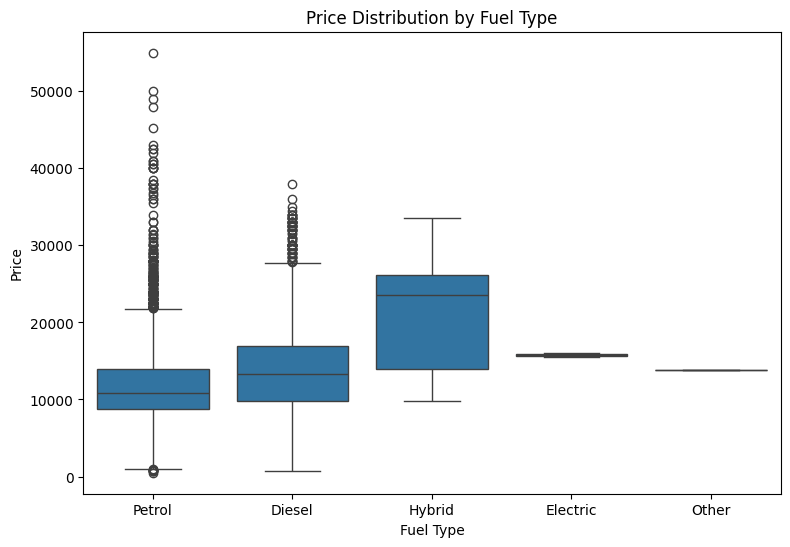

In [25]:
plt.figure(figsize=(9, 6))

sns.boxplot(data=df, x="fuelType", y="price")

plt.title("Price Distribution by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price")

plt.show()

### Observation

- Hybrid cars have a higher typical price in this dataset than Petrol and Diesel cars.
- Petrol is by far the most common fuel type.
- Hybrid, Electric, and Other have very few observations.
- The small sample sizes of Electric and Other mean we should not draw strong conclusions about their price distributions.
- Rare categories will not automatically be removed.

## Correlation Analysis

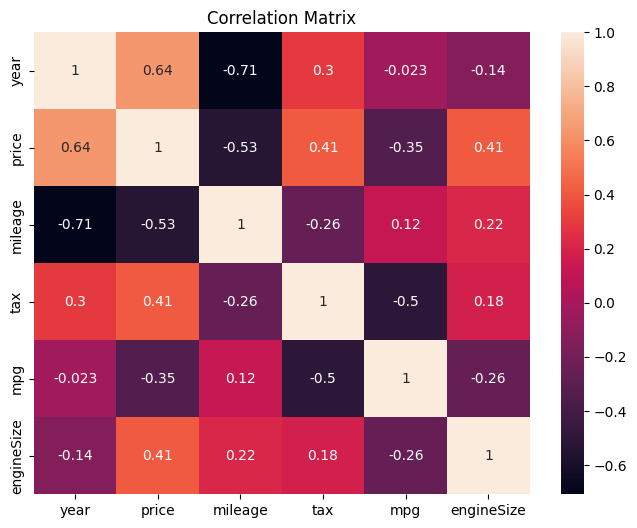

In [26]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df.select_dtypes(include="number").corr(),
    annot=True
)

plt.title("Correlation Matrix")
plt.show()

### Observation

- `year` has the strongest positive linear correlation with `price` (0.64).
- `mileage` has a moderate-to-strong negative correlation with `price` (-0.53).
- `tax` and `engineSize` both have moderate positive correlations with `price` (0.41).
- `mpg` has a moderate negative correlation with `price` (-0.35).
- `year` and `mileage` have a relatively strong negative correlation (-0.71), indicating potential multicollinearity.
- Correlation only measures pairwise linear relationships and does not determine whether a feature should be removed.

## Data Cleaning

In [27]:
df["model"] = df["model"].str.strip()

In [28]:
df["model"].unique()

array(['Fiesta', 'Focus', 'Puma', 'Kuga', 'EcoSport', 'C-MAX', 'Mondeo',
       'Ka+', 'Tourneo Custom', 'S-MAX', 'B-MAX', 'Edge',
       'Tourneo Connect', 'Grand C-MAX', 'KA', 'Galaxy', 'Mustang',
       'Grand Tourneo Connect', 'Fusion', 'Ranger', 'Streetka', 'Escort',
       'Transit Tourneo'], dtype=object)

In [29]:
df["model"].nunique()

23

In [30]:
df = df[df["year"] != 2060]

In [31]:
df["year"].max()

2020

In [32]:
df["engineSize"] = df["engineSize"].replace(0, np.nan)

In [33]:
df["engineSize"].isna().sum()

np.int64(51)

In [34]:
(df["engineSize"] == 0).sum()

np.int64(0)

In [35]:
df = df.drop_duplicates()

In [36]:
df.duplicated().sum()

np.int64(0)

## Skewness

In [ ]:
num_features = df.select_dtypes(include="number")
num_features.skew()

,0
year,-1.282601
price,1.096457
mileage,1.842068
tax,-0.564082
mpg,0.603923
engineSize,1.893121


### Skewness Analysis

The skewness of the numerical features was checked to understand their distributions.

- `mileage` and `engineSize` are strongly right-skewed.
- `price` is moderately right-skewed.
- `year` is moderately left-skewed.
- `tax` and `mpg` show relatively mild skewness.


## Checking Outlires

In [38]:
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = ((num_features < lower_bound) | (num_features > upper_bound)).sum()

outliers.sort_values(ascending=False)

,0
mileage,878
year,499
price,286
mpg,216
engineSize,190
tax,20


### Outlier Analysis

Potential outliers were identified using the **IQR (Interquartile Range) method**.

- `mileage`: 878 potential outliers
- `year`: 499 potential outliers
- `price`: 286 potential outliers
- `mpg`: 216 potential outliers
- `engineSize`: 190 potential outliers
- `tax`: 20 potential outliers

These observations were not removed because being outside the IQR range does not necessarily mean that they are invalid. For example, a car with unusually high mileage or price can still be a legitimate observation.

Therefore, the potential outliers will be retained.

## Train/Test Split

In [39]:
X = df.drop("price", axis= 1)
y = df["price"]

In [40]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (14248, 8)
X_test: (3563, 8)
y_train: (14248,)
y_test: (3563,)


In [42]:
num_cols = ["year", "mileage", "tax", "mpg", "engineSize"]
cat_cols = ["model", "transmission", "fuelType"]

## Preprocessing

In [43]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("numerical", num_pipeline, num_cols),
    ("categorical", cat_pipeline, cat_cols)
])

preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['year', 'mileage', 'tax', 'mpg',
                                  'engineSize']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['model', 'transmission', 'fuelType'])])

## Linear Regression

In [44]:
lr_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', LinearRegression())])

In [45]:
lr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', LinearRegression())])

In [46]:
lr_pred = lr_pipeline.predict(X_test)
lr_pred_train = lr_pipeline.predict(X_train)

In [47]:
lr_r2_test = r2_score(y_test, lr_pred)
lr_r2_train = r2_score(y_train, lr_pred_train)

lr_mae = mean_absolute_error(y_test, lr_pred)
lr_mse = mean_squared_error(y_test, lr_pred)
lr_rmse = np.sqrt(lr_mse)

print("R2 Score (Test):", lr_r2_test)
print("R2 Score (Train):", lr_r2_train)
print("MAE:", lr_mae)
print("MSE:", lr_mse)
print("RMSE:", lr_rmse)

R2 Score (Test): 0.8595918287895332
R2 Score (Train): 0.8480733475598876
MAE: 1342.6475331983543
MSE: 3227689.558396891
RMSE: 1796.5771785250115


## Ridge Regression

In [48]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', Ridge())])

In [49]:
ridge_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', Ridge())])

In [50]:
ridge_pred = ridge_pipeline.predict(X_test)
ridge_pred_train = ridge_pipeline.predict(X_train)

In [51]:
ridege_r2_test = r2_score(y_test, ridge_pred)
ridge_r2_train = r2_score(y_train, ridge_pred_train)

ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_mse = mean_squared_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(ridge_mse)

print("R2 Score (Test):", ridege_r2_test)
print("R2 Score (Train):", ridge_r2_train)
print("MAE:", ridge_mae)
print("MSE:", ridge_mse)
print("RMSE:", ridge_rmse)

R2 Score (Test): 0.8596847718288606
R2 Score (Train): 0.847941506471024
MAE: 1342.3711185133602
MSE: 3225552.992732824
RMSE: 1795.9824589156833


## Lasso Regression

In [52]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=1.0, max_iter=10000))
])

lasso_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', Lasso(max_iter=10000))])

In [53]:
lasso_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', Lasso(max_iter=10000))])

In [54]:
lasso_pred = lasso_pipeline.predict(X_test)
lasso_pred_train = lasso_pipeline.predict(X_train)

In [55]:
lasso_r2_test = r2_score(y_test, lasso_pred)
lasso_r2_train = r2_score(y_train, lasso_pred_train)

lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_mse = mean_squared_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(lasso_mse)

print("R2 Score (Test):", lasso_r2_test)
print("R2 Score (Train):", lasso_r2_train)
print("MAE:", lasso_mae)
print("MSE:", lasso_mse)
print("RMSE:", lasso_rmse)

R2 Score (Test): 0.8598811375594451
R2 Score (Train): 0.8474692375161006
MAE: 1341.6200268829564
MSE: 3221038.956172341
RMSE: 1794.7253149639198


## Polynomial Regression

In [56]:
from sklearn.preprocessing import PolynomialFeatures

poly_num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler())
])

poly_preprocessor = ColumnTransformer([
    ("numerical", poly_num_pipeline, num_cols),
    ("categorical", cat_pipeline, cat_cols)
])

poly_preprocessor

ColumnTransformer(transformers=[('numerical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('poly',
                                                  PolynomialFeatures(include_bias=False)),
                                                 ('scaler', StandardScaler())]),
                                 ['year', 'mileage', 'tax', 'mpg',
                                  'engineSize']),
                                ('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('onehot',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['model', 'transmission', 'fuelType'])])

In [57]:
poly_pipeline = Pipeline([
    ("preprocessor", poly_preprocessor),
    ("model", LinearRegression())
])

poly_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', LinearRegression())])

In [58]:
poly_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('poly',
                                                                   PolynomialFeatures(include_bias=False)),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', LinearRegression())])

In [59]:
poly_pred = poly_pipeline.predict(X_test)
poly_pred_train = poly_pipeline.predict(X_train)

In [60]:
poly_r2_test = r2_score(y_test, poly_pred)
poly_r2_train = r2_score(y_train, poly_pred_train)

poly_mae = mean_absolute_error(y_test, poly_pred)
poly_mse = mean_squared_error(y_test, poly_pred)
poly_rmse = np.sqrt(poly_mse)

print("R2 Score (Test):", poly_r2_test)
print("R2 Score (Train):", poly_r2_train)
print("MAE:", poly_mae)
print("MSE:", poly_mse)
print("RMSE:", poly_rmse)

R2 Score (Test): 0.8976644092602499
R2 Score (Train): 0.8854261461670905
MAE: 1154.1920132337493
MSE: 2352480.7341016484
RMSE: 1533.7798845015698


## Random Forest

In [61]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(random_state=42))
])

rf_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [62]:
rf_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model', RandomForestRegressor(random_state=42))])

In [63]:
rf_pred = rf_pipeline.predict(X_test)
rf_pred_train = rf_pipeline.predict(X_train)

In [64]:
rf_r2_test = r2_score(y_test, rf_pred)
rf_r2_train = r2_score(y_train, rf_pred_train)

rf_mae = mean_absolute_error(y_test, rf_pred)
rf_mse = mean_squared_error(y_test, rf_pred)
rf_rmse = np.sqrt(rf_mse)

print("R2 Score (Test):", rf_r2_test)
print("R2 Score (Train):", rf_r2_train)
print("MAE:", rf_mae)
print("MSE:", rf_mse)
print("RMSE:", rf_rmse)

R2 Score (Test): 0.9343773688171912
R2 Score (Train): 0.9895895315840352
MAE: 874.8204576210969
MSE: 1508526.744827316
RMSE: 1228.220967427


## Gradient Boosting

In [65]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    ))
])

gbr_pipeline

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

In [66]:
gbr_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model',
                 GradientBoostingRegressor(learning_rate=0.05, n_estimators=200,
                                           random_state=42))])

In [67]:
gbr_pred = gbr_pipeline.predict(X_test)
gbr_pred_train = gbr_pipeline.predict(X_train)

In [68]:
gbr_r2_test = r2_score(y_test, gbr_pred)
gbr_r2_train = r2_score(y_train, gbr_pred_train)

gbr_mae = mean_absolute_error(y_test, gbr_pred)
gbr_mse = mean_squared_error(y_test, gbr_pred)
gbr_rmse = np.sqrt(gbr_mse)

print("R2 Score (Test):", gbr_r2_test)
print("R2 Score (Train):", gbr_r2_train)
print("MAE:", gbr_mae)
print("MSE:", gbr_mse)
print("RMSE:", gbr_rmse)

R2 Score (Test): 0.9244926339893148
R2 Score (Train): 0.92147716020829
MAE: 955.9218560321211
MSE: 1735756.0799607725
RMSE: 1317.4809599993362


## Cross Validation

In [69]:
from sklearn.model_selection import KFold, cross_validate

kf = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": lr_pipeline,
    "Ridge Regression": ridge_pipeline,
    "Lasso Regression": lasso_pipeline,
    "Polynomial Regression": poly_pipeline,
    "Random Forest": rf_pipeline,
    "Gradient Boosting": gbr_pipeline
}

In [71]:
cv_results = {}

for name, model in models.items():
    scores = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring={
            "r2": "r2",
            "rmse": "neg_root_mean_squared_error"
        },
        n_jobs=-1
    )

    cv_results[name] = {
        "R2 Mean": scores["test_r2"].mean(),
        "R2 Std": scores["test_r2"].std(),
        "RMSE Mean": -scores["test_rmse"].mean(),
        "RMSE Std": scores["test_rmse"].std()
    }


In [72]:
cv_df = pd.DataFrame(cv_results).T
cv_df

,R2 Mean,R2 Std,RMSE Mean,RMSE Std
Linear Regression,0.847669,0.009060,1846.152084,53.002512
Ridge Regression,0.847660,0.009126,1846.227742,54.477459
Lasso Regression,0.847512,0.009232,1847.171242,57.242361
Polynomial Regression,0.886063,0.009789,1595.282302,53.375555
Random Forest,0.927924,0.004306,1269.900199,37.365711
Gradient Boosting,0.916102,0.006741,1369.458535,50.387820


## Random Forest - Tuning

In [73]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [10, 20, 30],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 1.0]
}

In [74]:
rf_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X, y)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['year',
                                                                                'mileage',
                                                                                'tax',
                                                                                'mpg',
                                                                                'engineSize']),
                                                                              ('categorical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEnco...
                                                                               ['model',
                                                                                'transmission',
                                                                                'fuelType'])])),
                                             ('model',
                                              RandomForestRegressor(random_state=42))]),
                   n_jobs=-1,
                   param_distributions={'model__max_depth': [10, 20, 30],
                                        'model__max_features': ['sqrt', 1.0],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5],
                                        'model__n_estimators': [100, 200, 300]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [75]:
print("Best Parameters:")
print(rf_search.best_params_)

Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 1.0, 'model__max_depth': 20}


In [76]:
print("Best CV RMSE:")
print(-rf_search.best_score_)

Best CV RMSE:
1395.5840583255338


In [77]:
best_rf = rf_search.best_estimator_

In [78]:
y_pred_best_rf = best_rf.predict(X_test)

In [79]:
mae_best_rf = mean_absolute_error(y_test, y_pred_best_rf)
mse_best_rf = mean_squared_error(y_test, y_pred_best_rf)
rmse_best_rf = np.sqrt(mse_best_rf)
r2_best_rf = r2_score(y_test, y_pred_best_rf)

print("R2 Score (Test):", r2_best_rf)
print("MAE:", mae_best_rf)
print("MSE:", mse_best_rf)
print("RMSE:", rmse_best_rf)

R2 Score (Test): 0.9757609282302289
MAE: 521.1275167701447
MSE: 557205.4545119741
RMSE: 746.4619578464626


In [80]:
y_pred_train_best_rf = best_rf.predict(X_train)

r2_train_best_rf = r2_score(y_train, y_pred_train_best_rf)

print("R2 Score (Train):", r2_train_best_rf)

R2 Score (Train): 0.9733478874192261


In [81]:
tuned_rf_cv = cross_validate(
    best_rf,
    X,
    y,
    cv=kf,
    scoring={
        "r2": "r2",
        "rmse": "neg_root_mean_squared_error"
    },
    n_jobs=-1
)

print("Mean CV R²:", tuned_rf_cv["test_r2"].mean())
print("Std CV R²:", tuned_rf_cv["test_r2"].std())

print("Mean CV RMSE:", -tuned_rf_cv["test_rmse"].mean())
print("Std CV RMSE:", tuned_rf_cv["test_rmse"].std())

Mean CV R²: 0.9331020665492835
Std CV R²: 0.004203568262701681
Mean CV RMSE: 1223.3779339243629
Std CV RMSE: 37.99430809279694


## Gradient Boosting - Tuning

In [82]:
gbr_param_dist = {
    "model__n_estimators": [100, 200, 300, 400],
    "model__learning_rate": [0.01, 0.03, 0.05, 0.1],
    "model__max_depth": [2, 3, 4, 5],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4]
}

In [83]:
gbr_search = RandomizedSearchCV(
    estimator=gbr_pipeline,
    param_distributions=gbr_param_dist,
    n_iter=15,
    cv=3,
    scoring="neg_root_mean_squared_error",
    random_state=42,
    n_jobs=-1,
    verbose=1
)

gbr_search.fit(X, y)

Fitting 3 folds for each of 15 candidates, totalling 45 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('numerical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('scaler',
                                                                                                StandardScaler())]),
                                                                               ['year',
                                                                                'mileage',
                                                                                'tax',
                                                                                'mpg',
                                                                                'engineSize']),
                                                                              ('categorical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('onehot',
                                                                                                OneHotEnco...
                                              GradientBoostingRegressor(learning_rate=0.05,
                                                                        n_estimators=200,
                                                                        random_state=42))]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'model__learning_rate': [0.01, 0.03,
                                                                 0.05, 0.1],
                                        'model__max_depth': [2, 3, 4, 5],
                                        'model__min_samples_leaf': [1, 2, 4],
                                        'model__min_samples_split': [2, 5, 10],
                                        'model__n_estimators': [100, 200, 300,
                                                                400]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=1)

In [84]:
print("Best Parameters:")
print(gbr_search.best_params_)

print("Best CV RMSE:")
print(-gbr_search.best_score_)

Best Parameters:
{'model__n_estimators': 300, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 4, 'model__learning_rate': 0.1}
Best CV RMSE:
1369.1042632918698


In [85]:
best_gbr = gbr_search.best_estimator_

y_pred_best_gbr = best_gbr.predict(X_test)

mae_best_gbr = mean_absolute_error(y_test, y_pred_best_gbr)
mse_best_gbr = mean_squared_error(y_test, y_pred_best_gbr)
rmse_best_gbr = np.sqrt(mse_best_gbr)
r2_best_gbr = r2_score(y_test, y_pred_best_gbr)

print("R2 Score (Test):", r2_best_gbr)
print("MAE:", mae_best_gbr)
print("MSE:", mse_best_gbr)
print("RMSE:", rmse_best_gbr)

R2 Score (Test): 0.9504425016741588
MAE: 780.553515994419
MSE: 1139223.0132163777
RMSE: 1067.3439057849994


In [86]:
y_pred_train_best_gbr = best_gbr.predict(X_train)

print("R2 Score (Train):", r2_score(y_train, y_pred_train_best_gbr))

R2 Score (Train): 0.9488312961625871


## Final Model Comparison

The models were compared using 5-fold cross-validation.  
Random Forest achieved the best overall performance, and after hyperparameter tuning, the Tuned Random Forest achieved the highest mean R² and lowest mean RMSE.

Therefore, **Tuned Random Forest** was selected as the final model.

In [87]:
final_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression",
        "Polynomial Regression",
        "Random Forest",
        "Gradient Boosting",
        "Tuned Random Forest"
    ],
    "Mean CV R2": [
        0.847669,
        0.847660,
        0.847512,
        0.886063,
        0.927924,
        0.916102,
        0.933102
    ],
    "Mean CV RMSE": [
        1846.152084,
        1846.227742,
        1847.171242,
        1595.282302,
        1269.900199,
        1369.458535,
        1223.377934
    ]
})

final_comparison

,Model,Mean CV R2,Mean CV RMSE
0,Linear Regression,0.847669,1846.152084
1,Ridge Regression,0.847660,1846.227742
2,Lasso Regression,0.847512,1847.171242
3,Polynomial Regression,0.886063,1595.282302
4,Random Forest,0.927924,1269.900199
5,Gradient Boosting,0.916102,1369.458535
6,Tuned Random Forest,0.933102,1223.377934


### Feature Importance

The model considers **year** the most important feature for predicting car price, followed by **engineSize**, **mileage**, and **mpg**. Some car models also contribute significantly, while `tax` and `transmission` have relatively lower importance.

In [95]:
best_rf_model = best_rf.named_steps["model"]
preprocessor = best_rf.named_steps["preprocessor"]
feature_names = preprocessor.get_feature_names_out()

importances = best_rf_model.feature_importances_

In [93]:
feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance_df = feature_importance_df.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_df

,Feature,Importance
0,numerical__year,4.951817e-01
4,numerical__engineSize,2.505161e-01
1,numerical__mileage,5.867813e-02
3,numerical__mpg,5.790849e-02
18,categorical__model_Kuga,3.259082e-02
10,categorical__model_Fiesta,2.119908e-02
17,categorical__model_Ka+,1.858155e-02
20,categorical__model_Mustang,1.546842e-02
8,categorical__model_Edge,1.027554e-02
2,numerical__tax,6.528553e-03


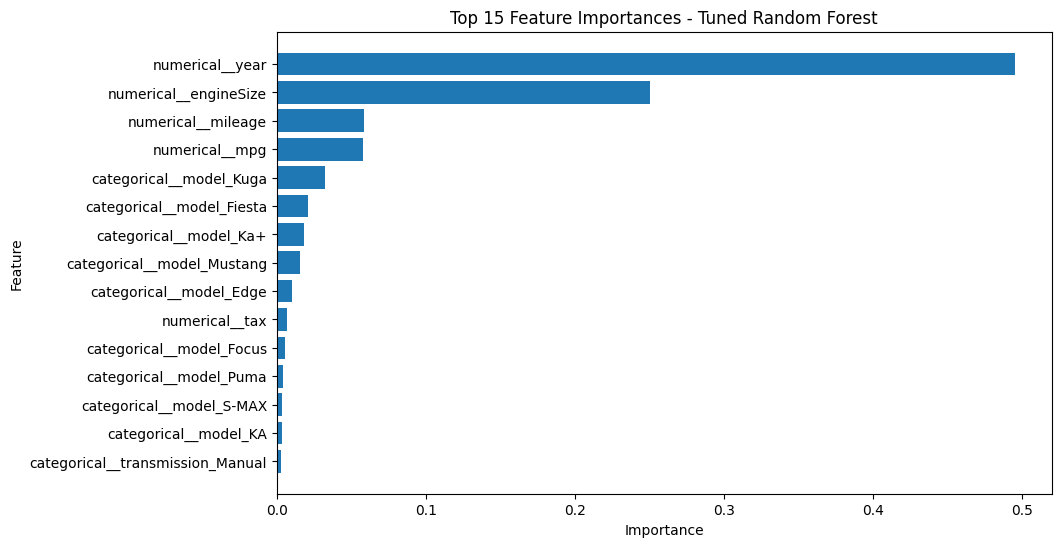

In [94]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))
plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances - Tuned Random Forest")
plt.show()

## Actual vs Predicted Prices

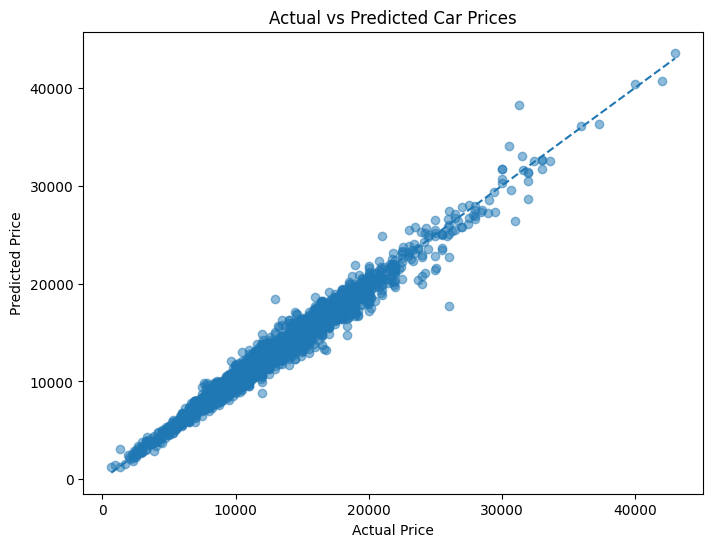

In [96]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred_best_rf, alpha=0.5)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

## Observation

Most predictions lie close to the diagonal line, indicating that the model predicts car prices well. A few points are farther from the line, representing larger prediction errors.

## Residual Analysis

Residuals represent the difference between the actual and predicted prices.

A good regression model should have residuals randomly scattered around zero without a clear pattern.

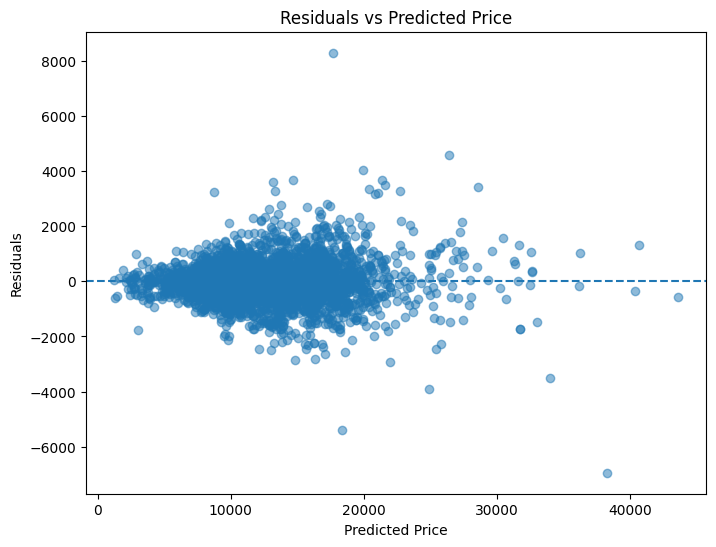

In [97]:
residuals = y_test - y_pred_best_rf

plt.figure(figsize=(8, 6))

plt.scatter(y_pred_best_rf, residuals, alpha=0.5)

plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Price")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Price")

plt.show()

### Observation

The residuals are generally centered around zero with no strong pattern, indicating that the model captures the main relationships well. However, the error spread increases for higher-priced cars, with a few larger residuals.

## Final Model Evaluation

The tuned Random Forest was selected as the final model based on its strong cross-validation performance.

The final model is evaluated on the held-out test set using MAE, MSE, RMSE, and R².

In [98]:
final_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [
        mae_best_rf,
        mse_best_rf,
        rmse_best_rf,
        r2_best_rf
    ]
})

final_metrics

,Metric,Value
0,MAE,521.127517
1,MSE,557205.454512
2,RMSE,746.461958
3,R²,0.975761


### Cross-Validation Performance

The final Tuned Random Forest achieved a mean **R² of 0.9331** and a mean **RMSE of 1223.38** across 5-fold cross-validation. These results provide a more reliable estimate of the model's generalization performance across different data splits.

### Final Test Performance

On the held-out test set, the Tuned Random Forest achieved an **R² of 0.9758**, **MAE of 521.13**, and **RMSE of 746.46**.

## Save The Model

In [99]:
import joblib

joblib.dump(best_rf, "ford_price_model.pkl")

['ford_price_model.pkl']

## Model Size Optimization

The tuned Random Forest was tested with different numbers of trees to reduce the model size while maintaining similar performance.

The 100-tree model achieved nearly the same 5-fold cross-validation performance as the 300-tree model while reducing the model size from approximately **164 MB to 46 MB**.

Therefore, the **100-tree Random Forest** was selected as the deployment model.

In [100]:
tree_counts = [300, 200, 150, 100]

rf_size_results = {}

for n_trees in tree_counts:
    rf_temp = Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestRegressor(
            n_estimators=n_trees,
            max_depth=20,
            min_samples_split=2,
            min_samples_leaf=2,
            max_features=1.0,
            random_state=42,
            n_jobs=-1
        ))
    ])

    scores = cross_validate(
        rf_temp,
        X,
        y,
        cv=kf,
        scoring={
            "r2": "r2",
            "rmse": "neg_root_mean_squared_error"
        },
        n_jobs=-1
    )

    rf_size_results[n_trees] = {
    "Mean CV R2": scores["test_r2"].mean(),
    "Mean CV RMSE": -scores["test_rmse"].mean(),
    "R2 Std": scores["test_r2"].std(),
    "RMSE Std": scores["test_rmse"].std()
}

rf_size_df = pd.DataFrame(rf_size_results).T
rf_size_df

,Mean CV R2,Mean CV RMSE,R2 Std,RMSE Std
300,0.933102,1223.377934,0.004204,37.994308
200,0.932889,1225.339031,0.004191,37.936467
150,0.932854,1225.652005,0.004138,36.830778
100,0.932819,1225.952537,0.004143,36.273681


In [103]:
rf_100 = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_split=2,
        min_samples_leaf=2,
        max_features=1.0,
        random_state=42,
        n_jobs=-1
    ))
])

rf_100.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year', 'mileage', 'tax',
                                                   'mpg', 'engineSize']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['model', 'transmission',
                                                   'fuelType'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, min_samples_leaf=2,
                                       n_jobs=-1, random_state=42))])

In [105]:
y_pred_100 = rf_100.predict(X_test)
y_pred_train_100 = rf_100.predict(X_train)
mae_100 = mean_absolute_error(y_test, y_pred_100)
mse_100 = mean_squared_error(y_test, y_pred_100)
rmse_100 = np.sqrt(mse_100)
r2_100 = r2_score(y_test, y_pred_100)
r2_100_train = r2_score(y_train, y_pred_train_100)

print("R2 Score (Test):", r2_100)
print("R2 Score (Train):", r2_100_train)
print("MAE:", mae_100)
print("MSE:", mse_100)
print("RMSE:", rmse_100)

R2 Score (Test): 0.939087013804479
R2 Score (Train): 0.9734207544554756
MAE: 843.9045251657805
MSE: 1400261.8780594214
RMSE: 1183.3266151234077


In [104]:
joblib.dump(rf_100, "ford_price_model_100.pkl")

['ford_price_model_100.pkl']

## Final Deployment Model

The 100-tree Random Forest was selected as the final deployment model.

### Cross-Validation Performance
- Mean CV R²: **0.9328**
- Mean CV RMSE: **1225.95**

### Test Set Performance
- R²: **0.9391**
- MAE: **843.90**
- RMSE: **1183.33**

### Model Size
- Approximately **46 MB**

The reduction from 300 to 100 trees resulted in only a very small decrease in cross-validation performance while significantly reducing the model size. This makes the 100-tree model more suitable for deployment.

## Project Conclusion

The Tuned Random Forest provided the best predictive performance among the tested models. 
To make the model more suitable for deployment, the number of trees was reduced from 300 to 100, resulting in a model size of approximately 46 MB with only a small change in cross-validation performance.

The 100-tree Random Forest was therefore selected as the deployment model.